**Import the libraries**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from xgboost import XGBClassifier

**Load the dataset**

In [3]:
df = pd.read_csv(r"C:\Users\chips\Desktop\HygionX Model Files\Datasets\synthetic_patient_dataset (1).csv")

df.head()

,symptoms,symptom_count,severity_score,red_flag_count,triage,disease
0,infertility;irregular menstruation;weight gain,3,5,0,low,Polycystic Ovary Syndrome
1,confusion;focal weakness;loss of sensation;slu...,4,19,4,emergency,Stroke
2,abdominal pain;diarrhea;weight loss,3,7,0,moderate,Crohns Disease
3,fatigue;fever;loss of smell;loss of taste,4,8,0,moderate,COVID-19
4,fatigue;leg swelling;rapid heartbeat;shortness...,4,13,1,urgent,Heart Failure


**Remove unknown cases**

In [4]:
df = df[df["disease"] != "unknown"]

df.shape

(69993, 6)

**Plot Disease Distribution**

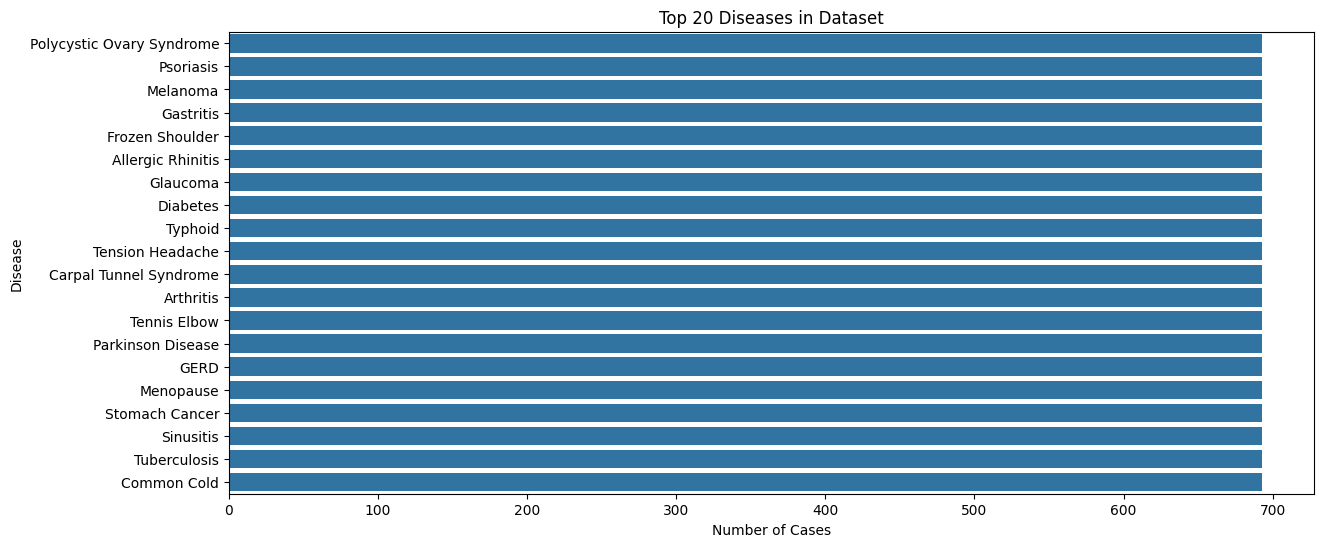

In [5]:
plt.figure(figsize=(14,6))

disease_counts = df["disease"].value_counts().head(20)

sns.barplot(x=disease_counts.values, y=disease_counts.index)

plt.title("Top 20 Diseases in Dataset")
plt.xlabel("Number of Cases")
plt.ylabel("Disease")

plt.show()

**Symptom count Distribution**

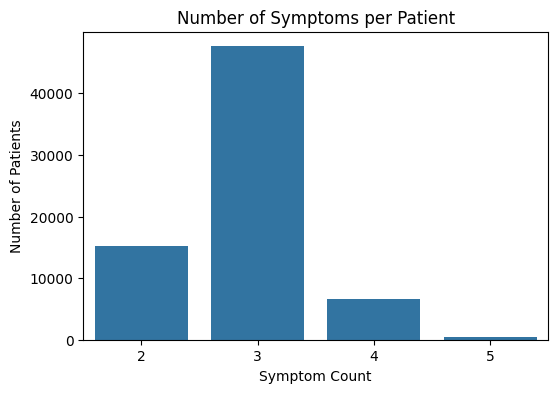

In [6]:
plt.figure(figsize=(6,4))

sns.countplot(x="symptom_count", data=df)

plt.title("Number of Symptoms per Patient")
plt.xlabel("Symptom Count")
plt.ylabel("Number of Patients")

plt.show()

**Convert symptoms to List**

In [7]:
df["symptom_list"] = df["symptoms"].apply(
    lambda x: sorted(x.split(";"))
)

**Convert to Binary Features**

In [8]:
mlb = MultiLabelBinarizer()

symptom_matrix = mlb.fit_transform(df["symptom_list"])

symptom_df = pd.DataFrame(symptom_matrix, columns=mlb.classes_)

**Features and Target**

In [9]:
X = symptom_df

y = df["disease"]

**Label Encoding**

In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_encoded = le.fit_transform(y)

**Train/Test Split**

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)

**Train XGBoost Model**

In [12]:
model = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=None,
              num_parallel_tree=None, ...)

**Saving the Disease Prediction Model**

In [15]:
import joblib
joblib.dump(model, r"C:\Users\chips\Desktop\HygionX Model Files\Models\m14 models\disease_model.pkl")

['C:\\Users\\chips\\Desktop\\HygionX Model Files\\Models\\m14 models\\disease_model.pkl']

**Saving the Label Encoder Model**

In [16]:
joblib.dump(le, r"C:\Users\chips\Desktop\HygionX Model Files\Models\m14 models\disease_label_encoder.pkl")

['C:\\Users\\chips\\Desktop\\HygionX Model Files\\Models\\m14 models\\disease_label_encoder.pkl']

**Saving the MultiLabelBinarizer**

In [17]:
joblib.dump(mlb, r"C:\Users\chips\Desktop\HygionX Model Files\Models\m14 models\symptom_vectorizer.pkl")

['C:\\Users\\chips\\Desktop\\HygionX Model Files\\Models\\m14 models\\symptom_vectorizer.pkl']

**Prediction**

In [18]:
pred = model.predict(X_test)

pred_labels = le.inverse_transform(pred)

**Accuracy Measurement**

In [19]:
print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.9717836988356311


**Feature Importance Plot**

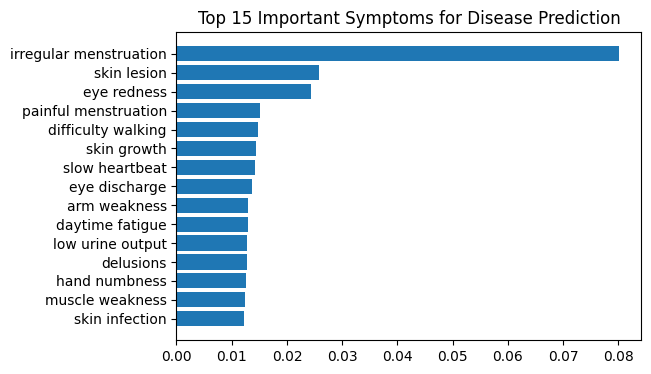

In [20]:
importances = model.feature_importances_

indices = np.argsort(importances)[-15:]

plt.figure(figsize=(6,4))

plt.barh(range(len(indices)), importances[indices])

plt.yticks(range(len(indices)), X.columns[indices])

plt.title("Top 15 Important Symptoms for Disease Prediction")

plt.show()

**Top 3 Disease Prediction**

In [21]:
probs = model.predict_proba(X_test)
top3 = np.argsort(probs, axis=1)[:, -3:][:, ::-1]

In [22]:
for i in range(5):
    print("Actual:", le.inverse_transform([y_test[i]])[0])
    print("Top3:", le.inverse_transform(top3[i]))
    print()

Actual: Parkinson Disease
Top3: ['Parkinson Disease' 'Back Strain' 'Alzheimers Disease']

Actual: Coronary Heart Disease
Top3: ['Coronary Heart Disease' 'Pneumonia' 'Heart Attack']

Actual: Acne
Top3: ['Acne' 'Dermatitis' 'Alzheimers Disease']

Actual: Gastritis
Top3: ['Gallstones' 'Gastritis' 'Food Poisoning']

Actual: Stomach Cancer
Top3: ['Stomach Cancer' 'Food Poisoning' 'Gallstones']



**Top 3 Accuracy**

In [23]:
top3_preds = top3
top3_accuracy = np.mean(
    [y_test[i] in top3[i] for i in range(len(y_test))]
)

print("Top-3 Accuracy:", top3_accuracy)


Top-3 Accuracy: 0.9996428316308308


**Confusion Matrix**

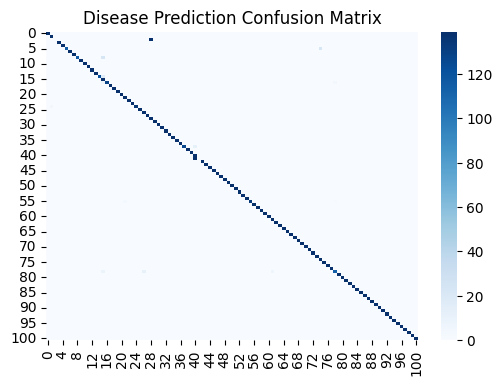

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm, cmap="Blues")

plt.title("Disease Prediction Confusion Matrix")

plt.show()

Test cases

In [25]:
import joblib
import numpy as np

model = joblib.load(r"C:\Users\chips\Desktop\HygionX Model Files\Models\m14 models\disease_model.pkl")
le = joblib.load(r"C:\Users\chips\Desktop\HygionX Model Files\Models\m14 models\disease_label_encoder.pkl")
mlb = joblib.load(r"C:\Users\chips\Desktop\HygionX Model Files\Models\m14 models\symptom_vectorizer.pkl")

In [26]:
def predict_disease(symptoms):

    # convert list → model input
    X_input = mlb.transform([symptoms])

    probs = model.predict_proba(X_input)[0]

    top3_idx = np.argsort(probs)[-3:][::-1]

    diseases = le.inverse_transform(top3_idx)
    scores = probs[top3_idx]

    print("\nPossible diseases:\n")

    for d, s in zip(diseases, scores):
        print(f"{d}  ({s:.2f})")

In [27]:
predict_disease(["fever","headache","chills"])
predict_disease(["skin rash","itching skin","skin redness"])
predict_disease(["blurred vision","eye pain","vision loss"])
predict_disease(["fatigue","weight gain","cold intolerance"])
predict_disease(["back pain","leg pain","numbness"])


Possible diseases:

Influenza  (1.00)
Malaria  (0.00)
Meningitis  (0.00)

Possible diseases:

Dermatitis  (1.00)
Ringworm  (0.00)
Allergic Rhinitis  (0.00)

Possible diseases:

Glaucoma  (0.55)
Cataract  (0.45)
Hypotension  (0.00)

Possible diseases:

Hypothyroidism  (1.00)
Obesity  (0.00)
Diabetes  (0.00)

Possible diseases:

Sciatica  (1.00)
Back Strain  (0.00)
Osteoporosis  (0.00)


In [33]:
tests = [

(["fever","cough","fatigue"], "Influenza"),

(["fever","headache","chills"], "Malaria"),

(["fever","rapid breathing","confusion"], "Sepsis"),

(["cough","shortness of breath","fatigue"], "Bronchitis"),

(["sneezing","runny nose","nasal congestion"], "Common Cold"),

(["headache","nausea","sensitivity to light"], "Migraine"),

(["memory loss","confusion","difficulty concentrating"], "Alzheimers Disease"),

(["seizures","confusion","loss of consciousness"], "Epilepsy"),

(["chest pain","shortness of breath","sweating"], "Heart Attack"),

(["palpitations","dizziness","fainting"], "Arrhythmia"),

(["abdominal pain","nausea","vomiting"], "Gastritis"),

(["burning abdominal pain","nausea","abdominal pain"], "Peptic Ulcer"),

(["diarrhea","abdominal pain","bloating"], "Irritable Bowel Syndrome"),

(["blood in stool","abdominal pain","weight loss"], "Colon Cancer"),

(["sharp abdominal pain","fever","nausea"], "Appendicitis"),

(["joint pain","joint swelling","joint stiffness"], "Arthritis"),

(["back pain","leg pain","numbness"], "Sciatica"),

(["muscle pain","fatigue","headache"], "Chronic Fatigue Syndrome"),

(["skin rash","itching skin","skin redness"], "Dermatitis"),

(["skin rash","swelling","allergic reaction"], "Food Allergy"),

(["blurred vision","eye pain","vision loss"], "Glaucoma"),

(["ear pain","ear discharge","hearing loss"], "Otitis Media"),

(["fever","joint pain","headache"], "Dengue"),

(["shortness of breath","wheezing","cough"], "Asthma"),

(["abdominal pain","vomiting","fever"], "Pancreatitis"),

(["weight gain","fatigue","cold intolerance"], "Hypothyroidism"),

(["excessive thirst","frequent urination","fatigue"], "Diabetes"),

(["bone pain","muscle weakness","fatigue"], "Vitamin D Deficiency"),

(["shoulder pain","shoulder stiffness","arm weakness"], "Frozen Shoulder"),

(["hand pain","hand numbness","arm weakness"], "Carpal Tunnel Syndrome")

]


In [34]:
correct_top1 = 0
correct_top3 = 0

for symptoms, actual in tests:

    X = mlb.transform([symptoms])
    probs = model.predict_proba(X)[0]

    top3_idx = np.argsort(probs)[-3:][::-1]
    preds = le.inverse_transform(top3_idx)

    print(symptoms, "->", preds, "| actual:", actual)

    if preds[0] == actual:
        correct_top1 += 1

    if actual in preds:
        correct_top3 += 1

print("\nTop-1 Accuracy:", correct_top1 / len(tests))
print("Top-3 Accuracy:", correct_top3 / len(tests))

['fever', 'cough', 'fatigue'] -> ['Pneumonia' 'COVID-19' 'Influenza'] | actual: Influenza
['fever', 'headache', 'chills'] -> ['Influenza' 'Malaria' 'Meningitis'] | actual: Malaria
['fever', 'rapid breathing', 'confusion'] -> ['Sepsis' 'Meningitis' 'Appendicitis'] | actual: Sepsis
['cough', 'shortness of breath', 'fatigue'] -> ['COPD' 'Bronchitis' 'Pneumonia'] | actual: Bronchitis
['sneezing', 'runny nose', 'nasal congestion'] -> ['Allergic Rhinitis' 'Common Cold' 'Sinusitis'] | actual: Common Cold
['headache', 'nausea', 'sensitivity to light'] -> ['Migraine' 'Hypertension' 'Influenza'] | actual: Migraine
['memory loss', 'confusion', 'difficulty concentrating'] -> ['Dementia' 'Alzheimers Disease' 'Stroke'] | actual: Alzheimers Disease
['seizures', 'confusion', 'loss of consciousness'] -> ['Epilepsy' 'Heat Stroke' 'Brain Tumor'] | actual: Epilepsy
['chest pain', 'shortness of breath', 'sweating'] -> ['Heart Attack' 'Pneumonia' 'Lung Cancer'] | actual: Heart Attack
['palpitations', 'dizzi